# Exploratory Data Analysis - MovieLens 100k
Collaborative filtering dataset, GroupLens Research (files.grouplens.org/datasets/movielens/ml-100k.zip).

Loads the three raw ML-100k files, cleans them, and explores ratings, users, and genres before any model is trained.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
%matplotlib inline

ROOT = Path.cwd()
DATA = ROOT / 'data' / 'ml-100k'
FIG = ROOT / 'figures'
FIG.mkdir(exist_ok=True)

## 1. Load raw files

In [2]:
ratings = pd.read_csv(DATA / 'u.data', sep='\t',
                       names=['user_id', 'item_id', 'rating', 'timestamp'])

genre_cols = ["unknown","Action","Adventure","Animation","Children's","Comedy","Crime",
              "Documentary","Drama","Fantasy","Film-Noir","Horror","Musical","Mystery",
              "Romance","Sci-Fi","Thriller","War","Western"]
item_cols = ['item_id','title','release_date','video_release_date','imdb_url'] + genre_cols
movies = pd.read_csv(DATA / 'u.item', sep='|', encoding='latin-1', names=item_cols)

users = pd.read_csv(DATA / 'u.user', sep='|',
                     names=['user_id','age','gender','occupation','zip_code'])

print('ratings raw shape:', ratings.shape)
print('movies  raw shape:', movies.shape)
print('users   raw shape:', users.shape)

ratings raw shape: (100000, 4)
movies  raw shape: (1682, 24)
users   raw shape: (943, 5)


## 2. Cleaning (missing values, duplicates, dtypes, orphan keys)

In [3]:
print('ratings missing values:\n', ratings.isna().sum())
print('\nratings duplicate rows:', ratings.duplicated().sum())
print('ratings duplicate (user_id,item_id) pairs:', ratings.duplicated(subset=['user_id','item_id']).sum())

ratings = ratings.drop_duplicates()
ratings['user_id'] = ratings['user_id'].astype(int)
ratings['item_id'] = ratings['item_id'].astype(int)
ratings['rating'] = ratings['rating'].astype(float)
ratings['timestamp'] = pd.to_datetime(ratings['timestamp'], unit='s')
print('\nrating value range:', ratings['rating'].min(), '-', ratings['rating'].max())

ratings missing values:
 user_id      0
item_id      0
rating       0
timestamp    0
dtype: int64

ratings duplicate rows: 0
ratings duplicate (user_id,item_id) pairs: 0

rating value range: 1.0 - 5.0


In [4]:
print('movies missing values:\n', movies.isna().sum()[movies.isna().sum() > 0])
print('movies duplicate item_id:', movies['item_id'].duplicated().sum())
movies = movies.drop_duplicates(subset=['item_id'])
movies['release_date'] = pd.to_datetime(movies['release_date'], errors='coerce')
movies['release_year'] = movies['release_date'].dt.year

movies missing values:
 release_date             1
video_release_date    1682
imdb_url                 3
dtype: int64
movies duplicate item_id: 0


In [5]:
print('users missing values:\n', users.isna().sum())
print('users duplicate user_id:', users['user_id'].duplicated().sum())
users = users.drop_duplicates(subset=['user_id'])
print('age range:', users['age'].min(), '-', users['age'].max())
print('gender values:', users['gender'].unique().tolist())
print('occupation count:', users['occupation'].nunique())

users missing values:
 user_id       0
age           0
gender        0
occupation    0
zip_code      0
dtype: int64
users duplicate user_id: 0
age range: 7 - 73
gender values: ['M', 'F']
occupation count: 21


In [6]:
orphan_users = ~ratings['user_id'].isin(users['user_id'])
orphan_items = ~ratings['item_id'].isin(movies['item_id'])
print('ratings referencing unknown user_id:', orphan_users.sum())
print('ratings referencing unknown item_id:', orphan_items.sum())

ratings.to_csv(ROOT / 'ratings_clean.csv', index=False)
movies.to_csv(ROOT / 'movies_clean.csv', index=False)
users.to_csv(ROOT / 'users_clean.csv', index=False)
print('\nsaved: ratings_clean.csv, movies_clean.csv, users_clean.csv')

ratings referencing unknown user_id: 0
ratings referencing unknown item_id: 0

saved: ratings_clean.csv, movies_clean.csv, users_clean.csv


## 3. Ratings distribution

In [7]:
ratings['rating'].describe().round(2)

count    100000.00
mean          3.53
std           1.13
min           1.00
25%           3.00
50%           4.00
75%           4.00
max           5.00
Name: rating, dtype: float64

In [8]:
ratings['rating'].value_counts().sort_index()

rating
1.0     6110
2.0    11370
3.0    27145
4.0    34174
5.0    21201
Name: count, dtype: int64

In [9]:
ratings_per_user = ratings.groupby('user_id').size()
ratings_per_item = ratings.groupby('item_id').size()
print('ratings per user - describe():\n', ratings_per_user.describe().round(1))
print('\nratings per movie - describe():\n', ratings_per_item.describe().round(1))
print('\nmatrix sparsity:', round(1 - len(ratings)/(943*1682), 4),
      '(fraction of the 943x1682 user-item matrix that is empty)')

ratings per user - describe():
 count    943.0
mean     106.0
std      100.9
min       20.0
25%       33.0
50%       65.0
75%      148.0
max      737.0
dtype: float64

ratings per movie - describe():
 count    1682.0
mean       59.5
std        80.4
min         1.0
25%         6.0
50%        27.0
75%        80.0
max       583.0
dtype: float64

matrix sparsity: 0.937 (fraction of the 943x1682 user-item matrix that is empty)


In [10]:
top10 = (ratings.groupby('item_id').size().sort_values(ascending=False).head(10)
         .rename('n_ratings').to_frame().join(movies.set_index('item_id')['title']))
top10

,n_ratings,title
item_id,,
50,583,Star Wars (1977)
258,509,Contact (1997)
100,508,Fargo (1996)
181,507,Return of the Jedi (1983)
294,485,Liar Liar (1997)
286,481,"English Patient, The (1996)"
288,478,Scream (1996)
1,452,Toy Story (1995)
300,431,Air Force One (1997)


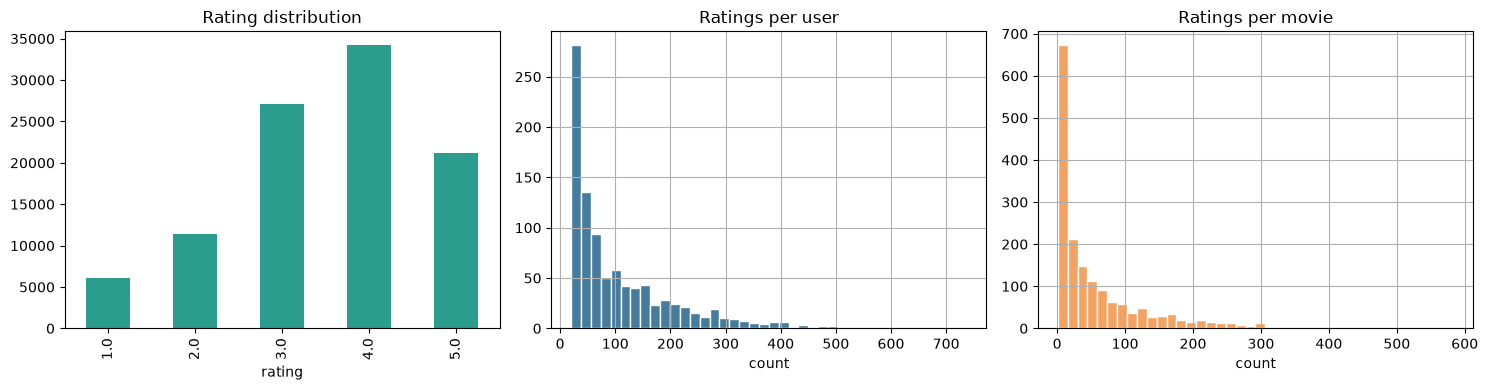

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ratings['rating'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='#2a9d8f')
axes[0].set_title('Rating distribution'); axes[0].set_xlabel('rating')
ratings_per_user.hist(bins=40, ax=axes[1], color='#457b9d', edgecolor='white')
axes[1].set_title('Ratings per user'); axes[1].set_xlabel('count')
ratings_per_item.hist(bins=40, ax=axes[2], color='#f4a261', edgecolor='white')
axes[2].set_title('Ratings per movie'); axes[2].set_xlabel('count')
plt.tight_layout()
plt.savefig(FIG / '01_ratings_overview.png', dpi=110)
plt.show()

## 4. User demographics

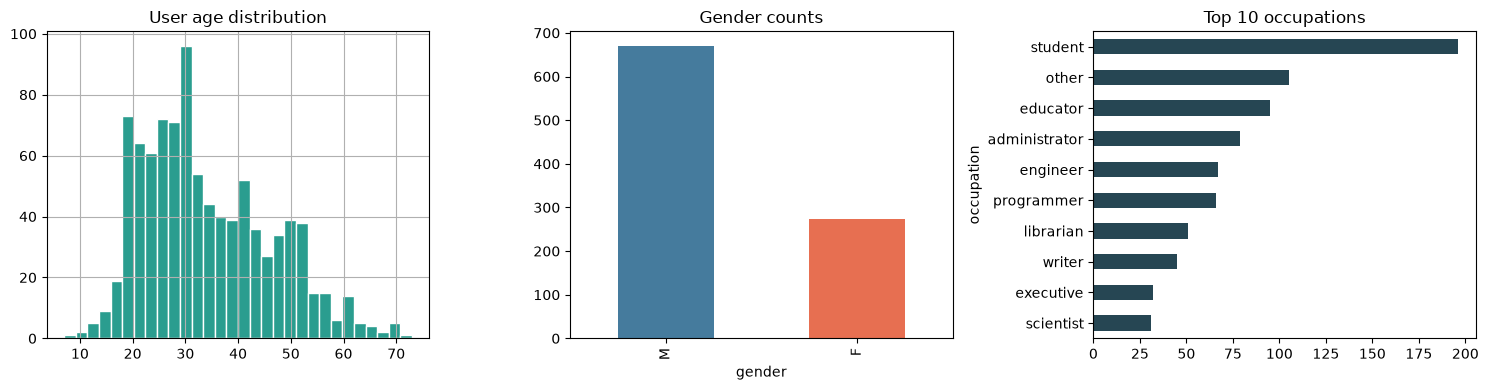

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
users['age'].hist(bins=30, ax=axes[0], color='#2a9d8f', edgecolor='white')
axes[0].set_title('User age distribution')
users['gender'].value_counts().plot(kind='bar', ax=axes[1], color=['#457b9d','#e76f51'])
axes[1].set_title('Gender counts')
users['occupation'].value_counts().head(10).plot(kind='barh', ax=axes[2], color='#264653')
axes[2].set_title('Top 10 occupations'); axes[2].invert_yaxis()
plt.tight_layout()
plt.savefig(FIG / '02_user_demographics.png', dpi=110)
plt.show()

## 5. Genre popularity and average rating by genre

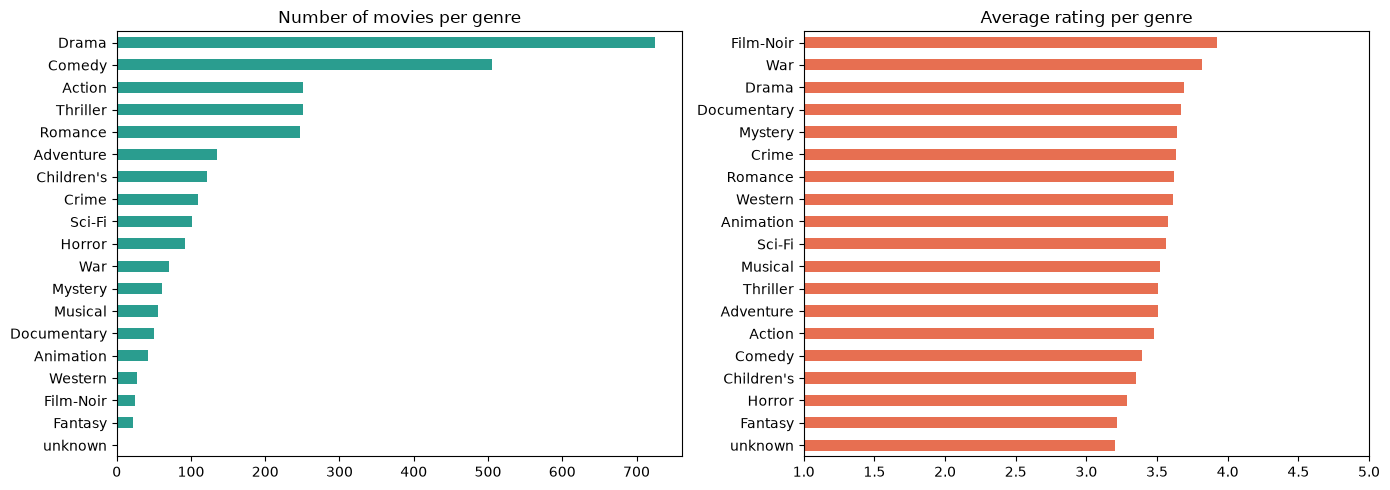

In [13]:
genre_counts = movies[genre_cols].sum().sort_values(ascending=False)
merged = ratings.merge(movies[['item_id'] + genre_cols], on='item_id')
genre_avg = pd.Series({g: merged.loc[merged[g] == 1, 'rating'].mean() for g in genre_cols}).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
genre_counts.plot(kind='barh', ax=axes[0], color='#2a9d8f'); axes[0].invert_yaxis()
axes[0].set_title('Number of movies per genre')
genre_avg.plot(kind='barh', ax=axes[1], color='#e76f51'); axes[1].invert_yaxis()
axes[1].set_title('Average rating per genre'); axes[1].set_xlim(1, 5)
plt.tight_layout()
plt.savefig(FIG / '03_genre_analysis.png', dpi=110)
plt.show()

In [14]:
genre_avg.round(3)

Film-Noir      3.922
War            3.816
Drama          3.687
Documentary    3.673
Mystery        3.638
Crime          3.632
Romance        3.622
Western        3.613
Animation      3.577
Sci-Fi         3.561
Musical        3.521
Thriller       3.509
Adventure      3.504
Action         3.480
Comedy         3.394
Children's     3.353
Horror         3.290
Fantasy        3.215
unknown        3.200
dtype: float64

## 6. Ratings volume over time

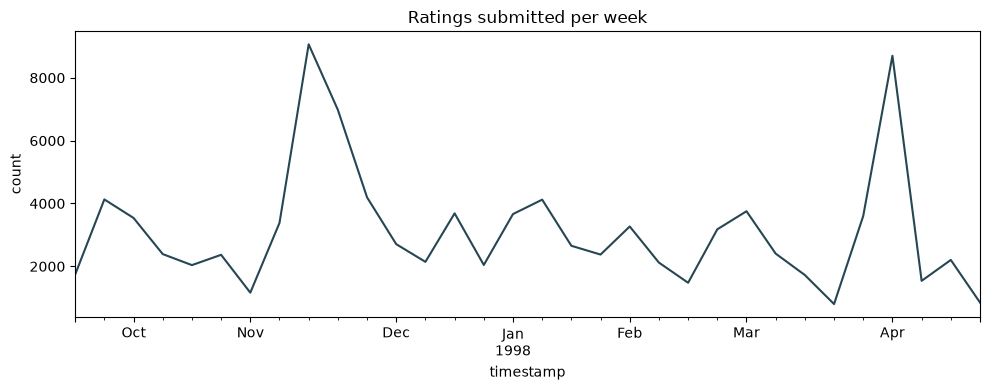

In [15]:
plt.figure(figsize=(10, 4))
ratings.set_index('timestamp').resample('W').size().plot(color='#264653')
plt.title('Ratings submitted per week'); plt.ylabel('count')
plt.tight_layout()
plt.savefig(FIG / '04_ratings_over_time.png', dpi=110)
plt.show()

## Summary
- 100,000 ratings, 943 users, 1,682 movies - zero missing values, duplicates, or orphan keys in `u.data`.
- Matrix sparsity ~93.7% - motivates collaborative filtering / matrix factorization (SVD) over a naive user-item lookup.
- Ratings are right-skewed toward positive (mean 3.53/5, mode = 4).
- Cleaned tables saved to `ratings_clean.csv`, `movies_clean.csv`, `users_clean.csv` for the modelling notebook.